# Heart Disease: Exploratory Data Analysis

In this notebook we explore the UCI Heart Disease (Cleveland) dataset before building any model. The goal is to understand what we have, so that our cleaning and modelling decisions are based on evidence.

**Source:** UCI Machine Learning Repository, dataset id 45.

**Questions we want to answer:**
1. How big is the dataset?
2. Which columns have missing values?
3. Is the target balanced?
4. Are there any impossible values?
5. How do the features relate to heart disease?

## 1. Loading the data

We download the dataset with `ucimlrepo`, which returns the features (`X`) and the target (`y`) separately. We join them into one table called `df`, and save a raw copy to `ml/data/` so that our training script can run later without needing the internet.

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)
df.to_csv("../data/heart_raw.csv", index=False)
print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2. Understanding the columns

Before analysing anything, we read what each column means. We print the dataset's metadata and its variable table, and compare them with the description on the UCI page.

In [2]:
print(heart_disease.metadata)
print(heart_disease.variables)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

Our notes on each column (to be checked against the table above):

| Column | Meaning |
|---|---|
| age | age in years |
| sex | 1 = male, 0 = female |
| cp | chest pain type (4 categories) |
| trestbps | resting blood pressure (mm Hg) |
| chol | serum cholesterol (mg/dl) |
| fbs | fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | resting ECG result (3 categories) |
| thalach | maximum heart rate achieved |
| exang | exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | slope of the peak exercise ST segment |
| ca | number of major vessels colored by fluoroscopy (0 to 3) |
| thal | thalassemia test result |
| num | target: 0 = no disease, 1 to 4 = disease severity |

Some of these are numbers but really represent categories (`cp`, `restecg`, `slope`, `thal`). We will need to encode them as categories later.

## 3. First look at the data

We check the data type of every column, count the missing values, and look at how the target `num` is distributed.

In [9]:
df.info()
print()
print(df.isna().sum())
print()
print(df["num"].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
 14  target    303 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 35.6 KB

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num     

## 4. Summary statistics and duplicates

We look at the range of each numeric column to spot impossible values (for example a cholesterol of 0) and to see how different the scales are. We also check for duplicate rows.

In [3]:
print("Duplicate rows:", df.duplicated().sum())
df.describe()

Duplicate rows: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 5. Turning the target into yes/no

The original target `num` runs from 0 (no disease) to 4 (severe). Predicta answers a yes/no question, so we group values 1 to 4 together as "disease". We store this in a new column `target`, and keep `num` for now only so we can compare the two. We will drop `num` before training, because leaving it in would hand the model the answer (data leakage).

In [4]:
df["target"] = (df["num"] > 0).astype(int)

print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).round(3))

target
0    164
1    139
Name: count, dtype: int64

target
0    0.541
1    0.459
Name: proportion, dtype: float64


## 6. Visualising the data

Numbers in a table only tell us so much. Here we plot the target balance and the distributions of the numeric columns, split by whether the patient has heart disease.

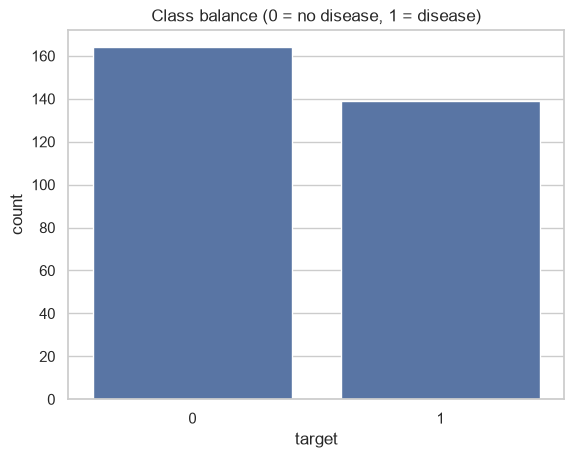

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sns.countplot(data=df, x="target")
plt.title("Class balance (0 = no disease, 1 = disease)")
plt.show()

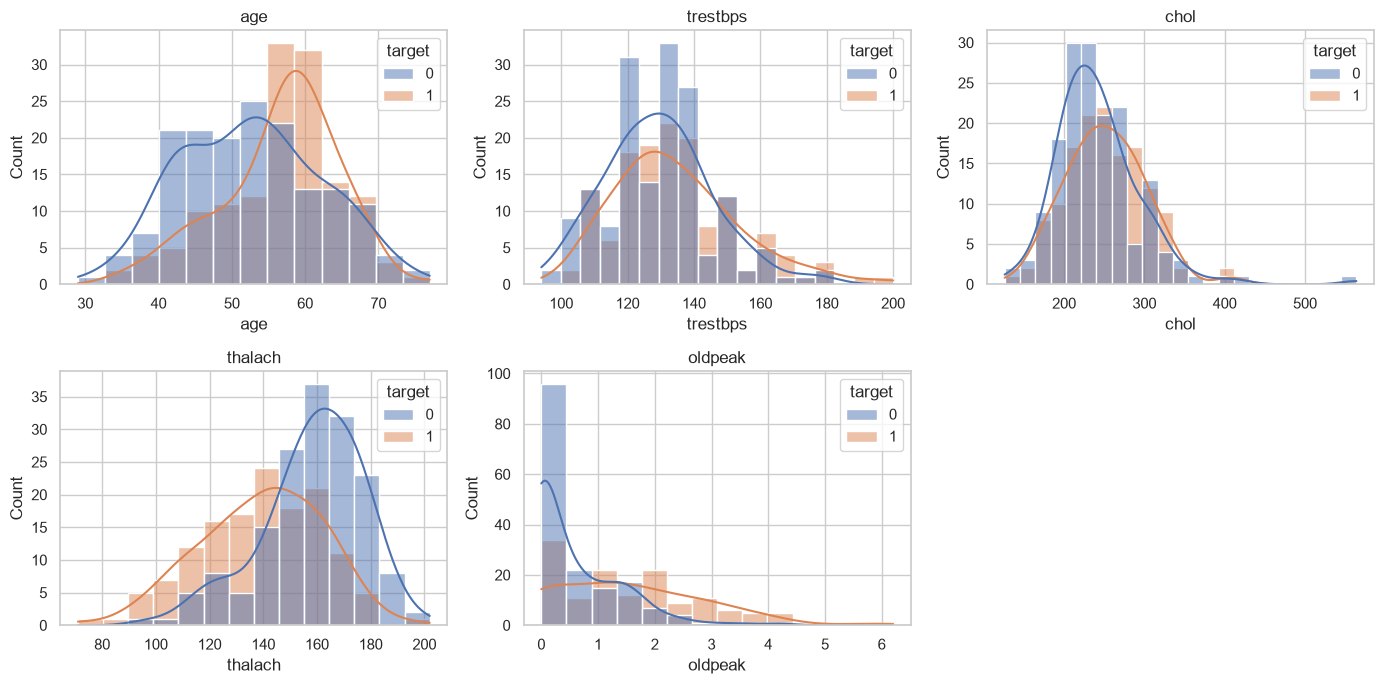

In [6]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

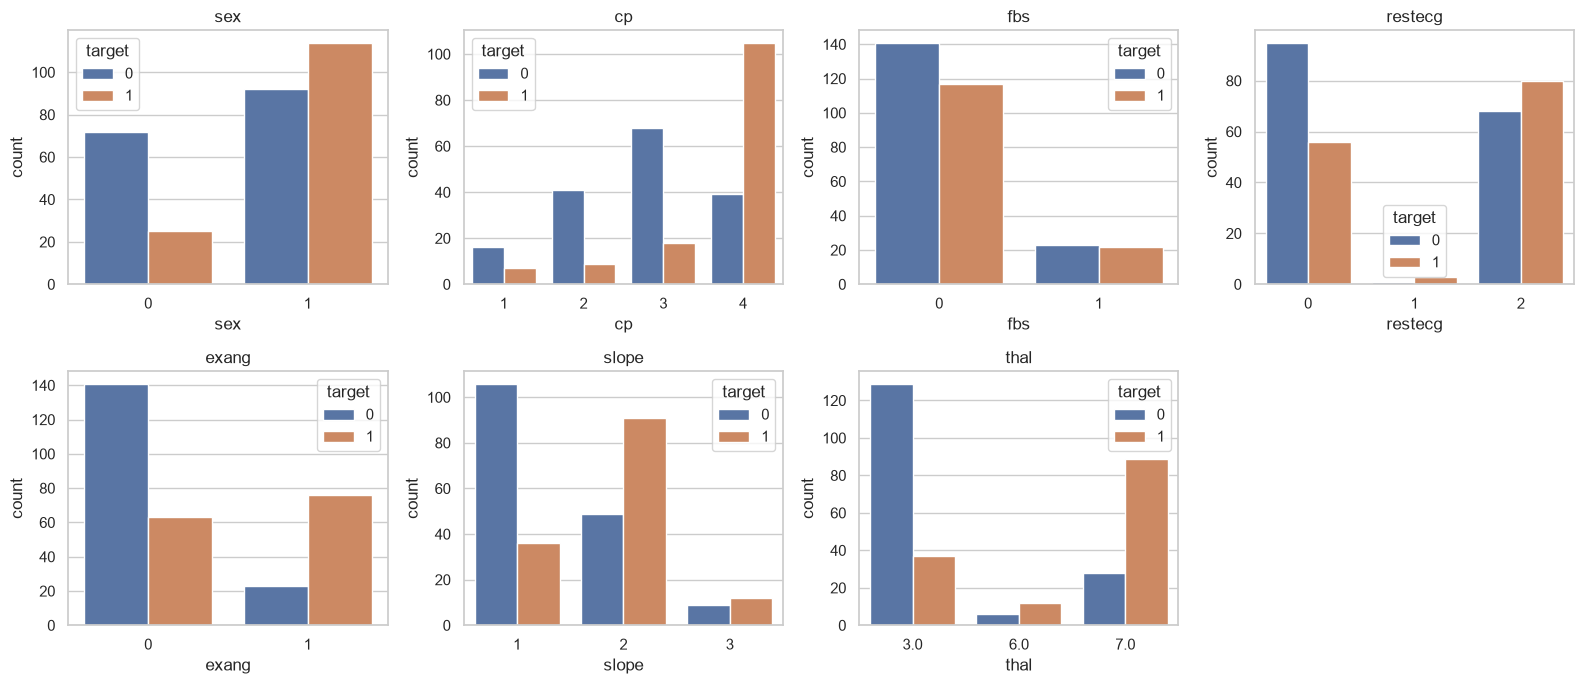

In [7]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, categorical_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## 7. Correlations

We check how strongly each numeric feature is related to the target and to the other features. Strongly correlated features carry similar information, and features with a clear link to the target are likely to be useful to the model.

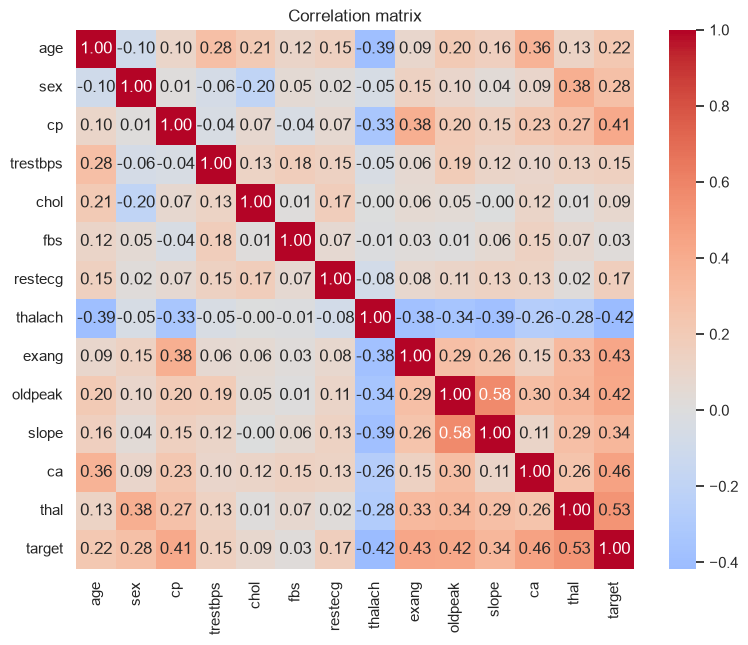

In [8]:
corr = df.drop(columns=["num"]).corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

## 8. Findings

- **Size:** 303 rows and 14 columns (13 features plus the original target `num`).
- **Missing values:** `ca` has 4 and `thal` has 2.
- **Duplicates:** 0.
- **Target balance:** 46% disease vs 54% no disease, so accuracy is a fair metric.
- **Impossible values:** none found. `chol` has a high outlier (564) that looks genuine, so we keep it.
- **Features that look most related to the target:** `thalach` (lower in disease), `oldpeak` (higher in disease), `cp` (type 4), `thal` (value 7), `exang`, and `slope`. `trestbps`, `chol` and `fbs` look weak.
- **Surprises:** the most common chest pain type among disease patients is `cp` = 4 (asymptomatic), not the typical painful types. Also, `chol` barely separates the two groups, which I expected it to do more.


## Next steps

1. Split the data into training and test sets (stratified).
2. Build a preprocessing pipeline: impute missing values, scale numeric columns, one-hot encode categorical columns.
3. Train a logistic regression baseline, then random forest and XGBoost.
4. Evaluate with recall, precision, F1 and ROC-AUC.